# Résolution numérique de l’équation de Black–Scholes

Projet compagnon EDP — CentraleSupélec

Ce notebook présente la résolution numérique de l’équation de Black–Scholes pour la valorisation
d’options européennes (call et put) et d’options barrières, à l’aide de différentes méthodes :
- différences finies explicites et implicites,
- méthodes de référence (formule fermée, arbre binomial, Monte-Carlo).



## Équation de Black–Scholes

Le prix $V(t,S)$ d’une option européenne satisfait l’équation de Black–Scholes :
$$
\partial_t V + \frac{1}{2}\sigma^2 S^2 \partial_{SS} V
+ rS \partial_S V - rV = 0,
\quad (t,S) \in (0,T)\times(0,S_{\max}).
$$

À maturité $t=T$, la condition finale est donnée par le payoff :
- Call : $V(T,S) = \max(S-K,0)$,
- Put : $V(T,S) = \max(K-S,0)$.


## Domaine tronqué et conditions aux limites

Le domaine spatial est tronqué à $(0,S_{\max})$.

### Problème aux limites d'un call européen

On considère une option européenne de type call, de prix d’exercice $K>0$ et de maturité $T>0$.
Le prix $V(t,S)$ satisfait l’équation de Black--Scholes sur le domaine $Q$, avec les conditions
aux limites et condition finale suivantes :
\begin{equation}
\left\{
\begin{aligned}
&\partial_t V + \frac{1}{2}\sigma^2 S^2 \partial_{SS} V
+ rS \partial_S V - rV = 0,
&& (t,S) \in (0,T)\times(0,S_{\max}), \\
&V(T,S) = \max(S-K,0),
&& S \in (0,S_{\max}), \\
&V(t,0) = 0,
&& t \in (0,T), \\
&V(t,S_{\max}) = S_{\max} - K e^{-r(T-t)},
&& t \in (0,T).
\end{aligned}
\right.
\end{equation}


### Problème aux limites d'un put européen

On considère une option européenne de type put, de prix d’exercice $K>0$ et de maturité $T>0$.
Le prix $V(t,S)$ satisfait l’équation de Black--Scholes sur le domaine $Q$, avec les conditions
aux limites et condition finale suivantes :
\begin{equation}
\left\{
\begin{aligned}
&\partial_t V + \frac{1}{2}\sigma^2 S^2 \partial_{SS} V
+ rS \partial_S V - rV = 0,
&& (t,S) \in (0,T)\times(0,S_{\max}), \\
&V(T,S) = \max(K-S,0),
&& S \in (0,S_{\max}), \\
&V(t,0) = K e^{-r(T-t)},
&& t \in (0,T), \\
&V(t,S_{\max}) = 0,
&& t \in (0,T).
\end{aligned}
\right.
\end{equation}

### Problème aux limites d'une option barrière knock-out de type call

On considère une option barrière down-and-out call, de prix d’exercice $K>0$,
de maturité $T>0$ et de barrière $B \in (0,S_{\max})$.
L’option est annulée dès que le sous-jacent atteint la barrière $S=B$.

Le prix $V(t,S)$ satisfait alors :
\begin{equation}
\left\{
\begin{aligned}
&\partial_t V + \frac{1}{2}\sigma^2 S^2 \partial_{SS} V
+ rS \partial_S V - rV = 0,
&& (t,S) \in (0,T)\times(B,S_{\max}), \\
&V(T,S) = \max(S-K,0),
&& S \in (B,S_{\max}), \\
&V(t,B) = 0,
&& t \in (0,T), \\
&V(t,S_{\max}) = S_{\max} - K e^{-r(T-t)},
&& t \in (0,T).
\end{aligned}
\right.
\end{equation}

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.stats as si
import time, timeit
# FEniCS
from dolfin import *

# ignorer l'erreur indiquant la dépreciation de pkg_resources

%matplotlib widget 
# permet la rotation des schémas 3D

## Paramètres financiers et numériques

In [13]:
# Paramètres financiers
sigma = 0.2       # volatilité
r = 0.05          # taux sans risque
K = 100.0         # strike
T = 1.0 # maturité
S0 = 100.5 # Prix initial que l'on utilisera : ce n'est pas 100 dû à la discrétisation en espace des différences finies.

# Domaine spatial
S_max = 3 * K




## Méthode des différences finies explicites



### Approximations des dérivées : 

$\partial_t V(t^{n+1},S_i) \approx \frac{V_i^{n+1} - V_i^n}{\Delta t}  $  
$\partial_S V(t^{n+1},S_i) \approx \frac{V_{i+1}^{n+1} - V_{i-1}^{n+1}}{2 \Delta S} $  
$\partial_{SS} V(t^{n+1},S_i) \approx \frac{V_{i+1}^{n+1} + V_{i-1}^{n+1} -  2 V_i^{n+1}}{(\Delta S)^2}$

On note l'équation de Black-Scholes :  

$$\dfrac{\partial V}{\partial t} + a(S) \dfrac{\partial^2 V}{\partial S^2} + b(S) \dfrac{\partial V}{\partial S} - c(S)V = 0$$


Cela donne :  
\begin{align*}
V_i^{n} &= A_i V_{i-1}^{n+1} + B_i V_i^{n+1} + C_i V_{i+1}^{n+1} \\
A_i &= \Delta t\left(\frac{a_i}{(\Delta S)^2} - \frac{b_i}{2\Delta S}\right) \\
B_i &= 1 - \Delta t\left(\frac{2a_i}{(\Delta S)^2} + c_i\right) \\
C_i &= \Delta t\left(\frac{a_i}{(\Delta S)^2} + \frac{b_i}{2\Delta S}\right) \\
\text{avec: } & a_i= \frac{1}{2}\sigma^2S_i^2,b_i=rS_i,c_i=r
\end{align*}

### Pour un Call et Put :

0.07489991188049316


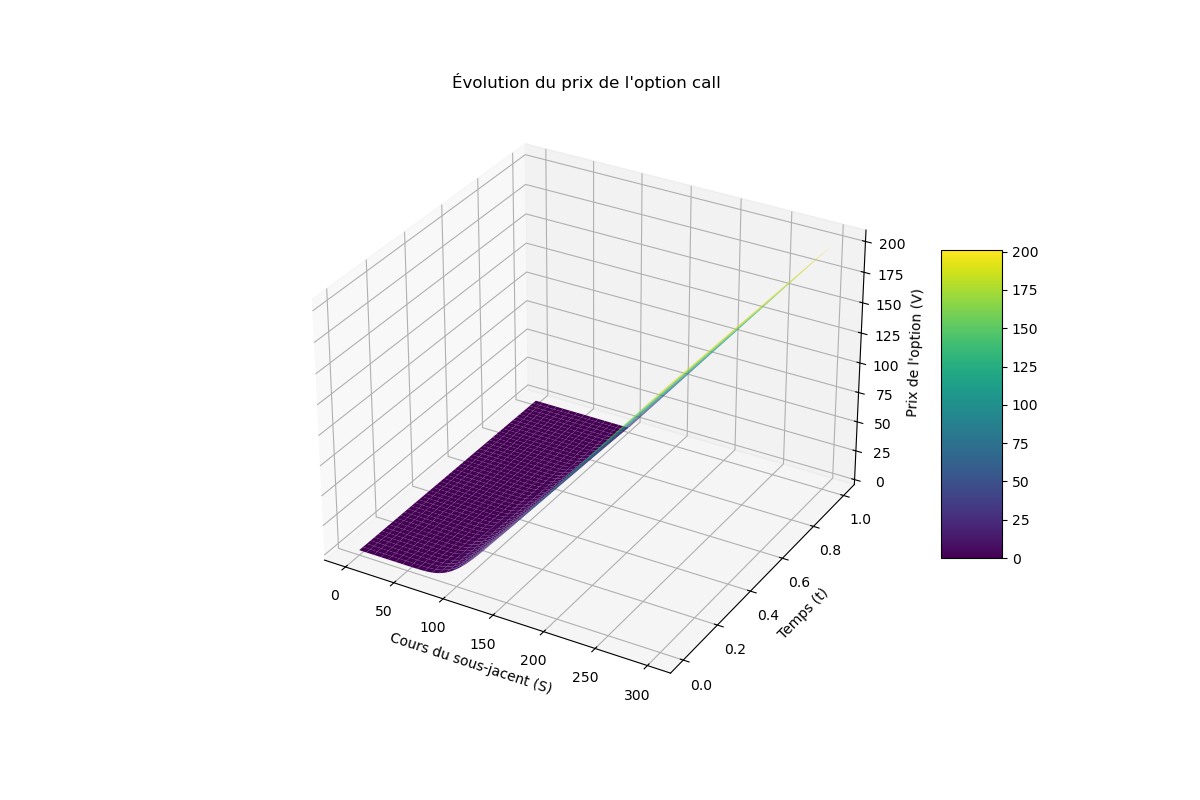

10.770529676510812


In [14]:
# Paramètres numériques
N_S = 200          # pas en espace
N_t = 20000         # pas en temps

grille = np.array
dS = S_max / N_S
dt = T / N_t

S = np.linspace(0, S_max, N_S + 1)
t = np.linspace(0, T, N_t + 1)
grid = np.zeros((N_t + 1, N_S + 1))


bcall = True # Pour un Put : paramètre à mettre à false
start_time = time.time()

def initialise_grille(b):
    if b:
        grid[-1, :] = np.maximum(S - K, 0)
        grid[:,0] = 0
        for n in range(N_t + 1):
            tau = T - t[n]
            grid[n,N_S ] = S_max - K*np.exp(-r * tau)
    else:
        grid[-1, :] = np.maximum(K - S, 0)
        grid[:,N_S ] = 0
        for n in range(N_t + 1):
            tau = T - t[n]
            grid[n,0 ] = K*np.exp(-r * tau)




# Initialisation (Call)
initialise_grille(bcall)

# Pré-calcul des coefficients (ils dépendent de S, pas de t)
S_int = S[1:-1] # Points intérieurs uniquement
a = 0.5 * sigma**2 * S_int**2
b = r * S_int
c = r

nu1 = dt / (dS**2)
nu2 = dt / dS

# Calcul des vecteurs de coefficients A, B, C
A = nu1 * a - 0.5 * nu2 * b
B = -2 * nu1 * a - r * dt 
C = nu1 * a + 0.5 * nu2 * b

# Boucle temporelle vectorisée (beaucoup plus rapide)
for n in range(N_t - 1, -1, -1):
    # Calcul de tous les points i d'un coup
    grid[n, 1:-1] = A * grid[n+1, 0:-2] + (1 + B) * grid[n+1, 1:-1] + C * grid[n+1, 2:]


S_mesh, t_mesh = np.meshgrid(S, t)

end_time = time.time()    # Fin du chrono

temps_ecoule_explicite = end_time - start_time
print(temps_ecoule_explicite)

#---------------------------------------------
#              Tracé de figure 
#---------------------------------------------

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

#Tracé de la surface
surf = ax.plot_surface(S_mesh, t_mesh, grid, cmap='viridis', edgecolor='none')

if bcall :
    ax.set_title("Évolution du prix de l'option call")
else:
    ax.set_title("Évolution du prix de l'option put")
ax.set_xlabel('Cours du sous-jacent (S)')
ax.set_ylabel('Temps (t)')
ax.set_zlabel('Prix de l\'option (V)')

# Ajouter une barre de couleur pour l'échelle
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()


indice_S0 = np.argmin(np.abs(S - S0))
prix_explicite  = grid[0, indice_S0]
print(prix_explicite)

## Adaptation aux Options Barrières (Down-and-Out)
La méthode des différences finies s'adapte très naturellement aux options barrières. Prenons l'exemple d'une option **Down-and-Out Call**.  
 Cette option se comporte comme un Call classique, mais elle est désactivée (vaut 0) si le sous-jacent touche ou passe en dessous d'une barrière $B$ avant la maturité.
Les modifications nécessaires sont :
- Domaine spatial : Le maillage ne commence plus à $S=0$, mais à $S=B$.
- Condition à la limite gauche : Au lieu d'une condition de dérivée ou de valeur nulle en 0, nous imposons strictement $V(t, B) = 0$ pour tout $t$.
- Pas d'espace : $\Delta S$ est recalculé comme $(S_{\max} - B) / N_S$.



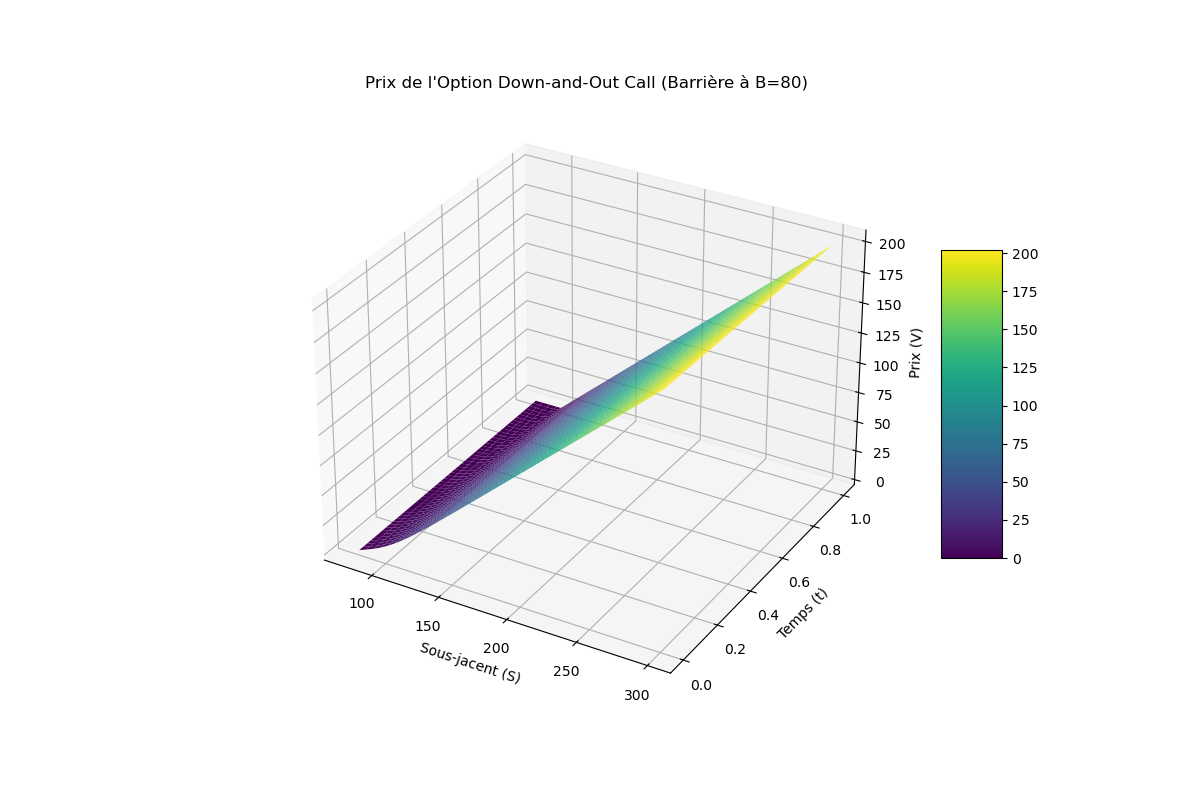

In [15]:
B = 80.0  # Niveau de la barrière (Down-and-Out : B < S0), et on met B<K pour voir les effets


dS = (S_max - B) / N_S
S = np.linspace(B, S_max, N_S + 1)
# l'indice 0 correspond à la barrière

dt = T / N_t
t = np.linspace(0, T, N_t + 1)


grid_barriere = np.zeros((N_t + 1, N_S + 1))


grid_barriere[-1, :] = np.maximum(S - K, 0)

grid_barriere[:, 0] = 0

for n in range(N_t + 1):
    tau = T - t[n]
    grid_barriere[n, N_S] = (S_max - K * np.exp(-r * tau))


# S[i] change car S commence à B 
i_values = np.arange(1, N_S)
S_int = S[1:-1] # S intérieur

alpha = 0.5 * dt * (sigma**2 * (S_int/dS)**2 - r * (S_int/dS))
beta  = 1 - dt * (sigma**2 * (S_int/dS)**2 + r)
gamma = 0.5 * dt * (sigma**2 * (S_int/dS)**2 + r * (S_int/dS))


for n in range(N_t - 1, -1, -1):
    grid_barriere[n, 1:-1] = (alpha * grid_barriere[n+1, 0:-2] + 
                              beta  * grid_barriere[n+1, 1:-1] + 
                              gamma * grid_barriere[n+1, 2:])
    
    # Ré-imposition de la condition barrière par sécurité
    grid_barriere[n, 0] = 0 

#---------------------------------------------
#              Tracé de figure 
#---------------------------------------------

from mpl_toolkits.mplot3d import Axes3D

S_mesh, t_mesh = np.meshgrid(S, t)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(S_mesh, t_mesh, grid_barriere, cmap='viridis', edgecolor='none')

ax.set_title("Prix de l'Option Down-and-Out Call (Barrière à B=80)")
ax.set_xlabel('Sous-jacent (S)')
ax.set_ylabel('Temps (t)')
ax.set_zlabel('Prix (V)')
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

## Détail du calcul de la condition de stabilité (CFL)
### Analyse de la Stabilité du Schéma Explicite
Le schéma explicite n'est pas inconditionnellement stable. Si le pas de temps $\Delta t$ est trop grand par rapport au pas d'espace $\Delta S$, des oscillations numériques apparaissent et la solution explose.
L'équation discrétisée au point $i$ s'écrit sous la forme :

$$V_i^n = A_i V_{i-1}^{n+1} + B_i V_{i}^{n+1} + C_i V_{i+1}^{n+1}$$
Avec le coefficient central $B_i$ valant :

$$B_i = 1 - \Delta t (\sigma^2 i^2 + r)$$
(où $i \approx S_i / \Delta S$)
Pour assurer la stabilité (principe du maximum), tous les coefficients ($A,B,C$) doivent rester positifs. En particulier, pour $A$ il faut $\frac{S_i}{\Delta S} \geq \frac{r}{\sigma} \approx 0,25$ ce qui est valable pour $\Delta S$ assez petit, et pour B cela impose :

$$1 - \Delta t (\sigma^2 i^2 + r) \ge 0 \quad \implies \quad \Delta t \le \frac{1}{\sigma^2 i^2 + r}$$
Comme cette condition doit être vraie pour tout $i$ du maillage (et le pire cas est pour $i$ grand, soit $\frac{S_{\max}}{\Delta S}$), la condition de stabilité CFL (Courant-Friedrichs-Lewy) devient approximativement :

$$\Delta t \le \frac{1}{\sigma^2 N_S^2} \approx \frac{\Delta S^2}{\sigma^2 S_{\max}^2}$$
Conséquence : Si on double la précision spatiale ($N_S \times 2$), on doit diviser le pas de temps par 4 ($N_t \times 4$). Cela rend la méthode explicite très coûteuse en temps de calcul pour une grande précision.


## Méthode des différences finies implicites



### Approximations des dérivées : 

$\partial_t V(t^n,S_i) \approx \frac{V_i^{n+1} - V_i^n}{\Delta t}  $  
$\partial_S V(t^n,S_i) \approx \frac{V_{i+1}^{n} - V_{i-1}^{n}}{2 \Delta S} $  
$\partial_{SS} V(t^{n},S_i) \approx \frac{V_{i+1}^{n} + V_{i-1}^{n} -  2 V_i^{n}}{(\Delta S)^2}$

On note l'équation de Black-Scholes :  

$$\dfrac{\partial V}{\partial t} + a(S) \dfrac{\partial^2 V}{\partial S^2} + b(S) \dfrac{\partial V}{\partial S} - c(S)V = 0$$

Contrairement à la méthode explicite, la méthode implicite évalue les dérivées spatiales au temps $t^n$ (le temps que l'on cherche à calculer) plutôt qu'au temps $t^{n+1}$ (le temps futur connu).

Cela transforme l'équation en un système linéaire à résoudre à chaque pas de temps. L'équation discrétisée devient :

$$
\frac{V_i^{n+1} - V_i^n}{\Delta t} + a_i \frac{V_{i+1}^{n} + V_{i-1}^{n} -  2 V_i^{n}}{(\Delta S)^2} + b_i  \frac{V_{i+1}^{n} - V_{i-1}^{n}}{2 \Delta S}  + c_i V_i^n = 0
$$
En regroupant les termes par $V^n$ (les inconnues) à gauche et $V^{n+1}$ (connu) à droite, nous obtenons un système de la forme :

$$
\alpha_i V_{i-1}^n + \beta_i V^n_i + \gamma_i V^n_{i+1} = V_i^{n+1}
$$
Avec les coefficients suivants pour les points intérieurs ($i=1, \dots, N_s-1$) :

\begin{align*} 
\alpha_i &= \Delta t \left( -\frac{a_i}{(\Delta S)^2} + \frac{b_i}{2\Delta S} \right) \\
\beta_i &= 1 + \Delta t \left( \frac{2a_i}{(\Delta S)^2} + c_i \right) \\ 
\gamma_i &= \Delta t \left( -\frac{a_i}{(\Delta S)^2} - \frac{b_i}{2\Delta S} \right) \end{align*}

Ce système s'écrit sous forme matricielle $MV^n = V^{n+1} + $ Conditions aux bords, où M est une matrice tridiagonale. L'avantage majeur de cette méthode est qu'elle est inconditionnellement stable, ce qui permet d'utiliser des pas de temps Δt plus grands sans que la solution n'explose.


0.00754094123840332


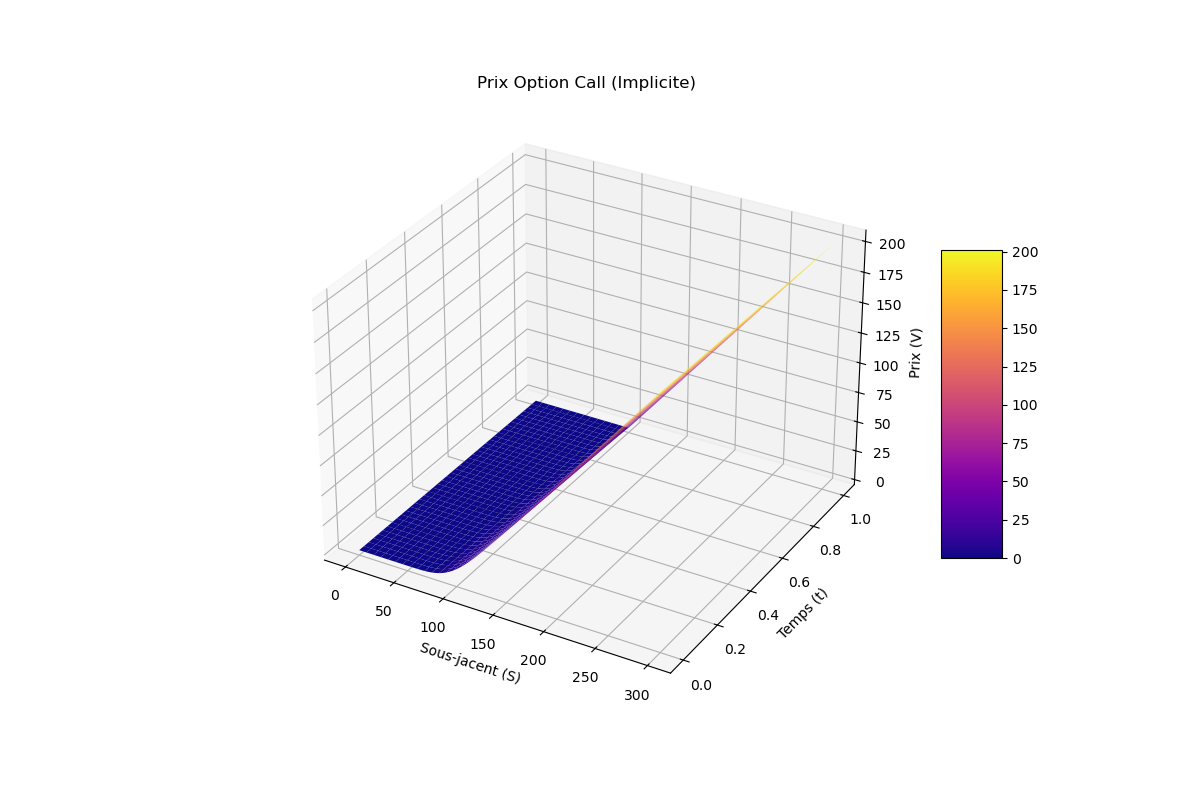

In [16]:
N_S = 200          # On n'a plus de condition de stabilité
N_t = 200

dS = S_max / N_S
dt = T / N_t


S = np.linspace(0, S_max, N_S + 1)
t = np.linspace(0, T, N_t + 1)
grid_implicite = np.zeros((N_t + 1, N_S + 1))
S_int = S[1:-1] # Points intérieurs

start_time = time.time()
bcall = True


if bcall:
    grid_implicite[-1, :] = np.maximum(S - K, 0)
else:
    grid_implicite[-1, :] = np.maximum(K - S, 0)

a = 0.5 * sigma**2 * S_int**2
b = r * S_int
c = r


# Facteurs communs
f1 = dt / (dS**2)
f2 = dt / (2 * dS)

alpha = -a * f1 + b * f2  # Diagonale inférieure
beta  = 1 + 2 * a * f1 + c * dt # Diagonale principale
gamma = -a * f1 - b * f2  # Diagonale supérieure


# Nous utilisons numpy pour créer la matrice mais il ne faut pas avoir une discrétisation trop grande.
from numpy import diag

M = diag(beta) + diag(alpha[1:], -1) + diag(gamma[:-1], 1)

M_inv = np.linalg.inv(M) # Note : l'algo de Thomas est plus efficace en O(n) pour les systèmes tridiagonaux


for n in range(N_t - 1, -1, -1):
    V_next = grid_implicite[n+1, 1:-1]
    
    tau = T - t[n]
    if bcall:
        V_0 = 0
        V_NS = S_max - K * np.exp(-r * tau)
    else:
        V_0 = K * np.exp(-r * tau)
        V_NS = 0
        
    grid_implicite[n, 0] = V_0
    grid_implicite[n, N_S] = V_NS
    
    RHS = V_next.copy()
    RHS[0] -= alpha[0] * V_0
    RHS[-1] -= gamma[-1] * V_NS
    
    # Résolution du système linéaire
    V_current_int = np.dot(M_inv, RHS)
    
    grid_implicite[n, 1:-1] = V_current_int

end_time = time.time() 
temps_ecoule_implicite = end_time - start_time
print(temps_ecoule_implicite)

#---------------------------------------------
#              Tracé de figure 
#---------------------------------------------

S_mesh, t_mesh = np.meshgrid(S, t)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(S_mesh, t_mesh, grid_implicite, cmap='plasma', edgecolor='none')

titre = "Prix Option Call (Implicite)" if bcall else "Prix Option Put (Implicite)"
ax.set_title(titre)
ax.set_xlabel('Sous-jacent (S)')
ax.set_ylabel('Temps (t)')
ax.set_zlabel('Prix (V)')
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

indice_S0 = np.argmin(np.abs(S - S0))
prix_implicite  = grid_implicite[0, indice_S0]

## Formule fermée pour les call et put européens

Pour les call et put européens, on dispose d'une formule exact pour les call et put :

### Call
$$
V(t,S) = S N(d_1) - Ke^{-r(T-t)} N(d_2)
$$
avec 
$$
d_1 = \frac{ln(\frac{S}{K}) + (r+\frac{\sigma^2}{2})(T-t)}{\sigma \sqrt{T-t}}
$$
et
$$
d_2 = d_1 - \sigma \sqrt{T-t}
$$
$N$ étant la fonction de répartition de la loi normale centrée réduite.
### Put 
$$
V(t,S) = - S N(- d_1) + Ke^{-r(T-t)} N(-d_2)
$$
avec $d_1$ et $d_2$ définis précédemment.

In [17]:
def black_scholes_formula(S, K, T, r, sigma, option_type="call"): 
    # Calcul de d1 et d2
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == "call":
        price = S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)
    else:
        raise ValueError("option_type doit être 'call' ou 'put'")
        
    return price


print(f"Prix du Call : {black_scholes_formula(S0, K, T, r, sigma, 'call'):.4f}")
print(f"Prix du Put : {black_scholes_formula(S0, K, T, r, sigma, 'put'):.4f}")

Prix du Call : 10.7713
Prix du Put : 5.3943


## Méthode de Monte Carlo

La méthode de Monte Carlo est une méthode numérique permettant d’estimer le prix d’options financières en simulant un grand nombre de trajectoires possibles du sous-jacent.  
Elle est particulièrement utile lorsque la formule analytique n’est pas disponible ou difficile à exploiter (donc dans notre cas elle est peu intéressante, mais s'avère efficace pour des options exotiques par exemple).

On suppose que le prix du sous-jacent \( S_t \) suit un mouvement brownien géométrique :

$$
dS_t = r S_t \, dt + \sigma S_t \, dW_t
$$
Et dans le cas des options européennes, le payoff dépend uniquement du prix du sous-jacent à la maturité.

$$
S_T = S_0 \exp\left( (r - \tfrac{1}{2}\sigma^2)T + \sigma \sqrt{T} Z \right)
$$


### Principe de la méthode de Monte Carlo

La méthode de Monte Carlo repose sur les étapes suivantes :

1. Simuler un grand nombre de réalisations indépendantes de la variable aléatoire ($ Z \sim \mathcal{N}(0,1) $)
2. Calculer les valeurs correspondantes du prix du sous-jacent à maturité ($S_T$)
3. Évaluer le payoff de l’option pour chaque trajectoire simulée
4. Calculer la moyenne des payoffs obtenus
5. Actualiser cette moyenne au taux sans risque


$$
\text{Prix} = e^{-rT} \, \mathbb{E}[\text{Payoff}]
$$




In [18]:
def monte_carlo_european_option(
    S0,     # Prix initial
    K,      # Strike
    T,      # Maturité
    r,      # Taux sans risque
    sigma,  # Volatilité
    N,      # Nombre de simulations
    option_type="call"
):

    Z = np.random.standard_normal(N)
    
    # Simulation du prix à maturité
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    

    if option_type == "call":
        payoff = np.maximum(ST - K, 0)
    elif option_type == "put":
        payoff = np.maximum(K - ST, 0)
    else:
        raise ValueError("option_type doit être 'call' ou 'put'")
    
    # Actualisation
    price = np.exp(-r * T) * np.mean(payoff)
    
    return price


N = 1_000_000

call_price = monte_carlo_european_option(S0, K, T, r, sigma, N, "call")
put_price  = monte_carlo_european_option(S0, K, T, r, sigma, N, "put")

print(f"Prix du Call européen : {call_price:.4f}")
print(f"Prix du Put européen  : {put_price:.4f}")

Prix du Call européen : 10.7861
Prix du Put européen  : 5.4087


## Méthode des arbres binomiaux pour le pricing des options européennes

La méthode des arbres binomiaux est une méthode numérique discrète permettant de calculer le prix des options en modélisant l’évolution du prix du sous-jacent sur un nombre fini de périodes. Elle repose sur l’idée que, sur un petit intervalle de temps, le prix du sous-jacent peut évoluer selon deux scénarios possibles : une hausse ou une baisse.



On considère une période de temps totale \( T \) découpée en \( N \) pas de temps de longueur :

$$
\Delta t = \frac{T}{N}
$$

À chaque pas de temps, le prix du sous-jacent évolue selon :

- une **hausse** avec un facteur $( u) $
- une **baisse** avec un facteur $( d )$

Dans le modèle de *Cox–Ross–Rubinstein* :

$$
u = e^{\sigma \sqrt{\Delta t}}, \quad d = e^{-\sigma \sqrt{\Delta t}}
$$

où  $\sigma $ est la volatilité du sous-jacent.



Sous la probabilité risque-neutre, la probabilité d’une hausse est donnée par :

$$
p = \frac{e^{r \Delta t} - d}{u - d}
$$

et la probabilité d’une baisse est $ 1 - p$  (on rappelle que $r $ est le taux d’intérêt sans risque).

Le prix du sous-jacent au nœud $(i, j) $, correspondant à $i $ hausses et $ j $ baisses après $ n = i + j $ périodes, est donné par :

$$
S_{n,i} = S_0 u^i d^{n-i}
$$

où $ S_0 $ est le prix initial du sous-jacent.


Avec nos conditions terminales, on peut donc calculer le prix de l'option à maturité.

Le prix de l’option est obtenu par rétro-propagation. À chaque nœud de l’arbre, la valeur de l’option est égale à l’espérance risque-neutre de sa valeur future, actualisée :

$$
V_n = e^{-r \Delta t} \left( p V_{n+1}^{\text{up}} + (1 - p) V_{n+1}^{\text{down}} \right)
$$

Cette étape est répétée jusqu’à revenir au temps initial. La valeur obtenue au nœud initial correspond au prix de l’option européenne.

Lorsque le nombre de pas $ N $ augmente, le prix issu du modèle binomial converge vers le prix donné par le modèle de Black–Scholes.

In [19]:


def binomial_european_option(
    S0,     # Prix initial
    K,      # Strike
    T,      # Maturité
    r,      # Taux sans risque
    sigma,  # Volatilité
    N,      # Nombre de pas
    option_type="call"
):
    dt = T / N
    
    u = np.exp(sigma * np.sqrt(dt))
    d = np.exp(-sigma * np.sqrt(dt))
    
    # Probabilité risque-neutre
    p = (np.exp(r * dt) - d) / (u - d)
    
    # Prix du sous-jacent à maturité
    ST = np.array([S0 * u**j * d**(N - j) for j in range(N + 1)])
    

    if option_type == "call":
        option_values = np.maximum(ST - K, 0)
    elif option_type == "put":
        option_values = np.maximum(K - ST, 0)
    else:
        raise ValueError("option_type doit être 'call' ou 'put'")
    

    actualise = np.exp(-r * dt)
    for _ in range(N):
        option_values = actualise * (p * option_values[1:] + (1 - p) * option_values[:-1])
    
    return option_values[0]

N = 500

call_price = binomial_european_option(S0, K, T, r, sigma, N, "call")
put_price  = binomial_european_option(S0, K, T, r, sigma, N, "put")

print(f"Prix du Call européen : {call_price:.4f}")
print(f"Prix du Put européen  : {put_price:.4f}")

Prix du Call européen : 10.7734
Prix du Put européen  : 5.3963


## Comparaison des méthodes : précision et temps d'exécution

On compare ici les différentes méthodes de valorisation pour un **call européen at-the-money** ($S_0 = 100.5,  K = 100$) avec les paramètres du notebook ($\sigma=0.2$, $r=0.05$, $T=1$).

La **formule fermée de Black–Scholes** sert de référence (valeur exacte).

Pour chaque méthode numérique on mesure :
- l'**erreur absolue** $|\hat{V} - V_{\text{BS}}|$ en dollars,
- le **temps d'exécution** moyen (via `timeit`, 5 runs).


In [20]:
# ── Référence Black-Scholes ───────────────────────────────────────────────────
V_ref = black_scholes_formula(S0, K, T, r, sigma, 'call')

# ── Récupération des prix DF depuis les grilles déjà calculées ────────────────
# Les grilles grid et grid_implicite ont été calculées dans les cellules précédentes.
# La ligne 0 correspond à t=0 (prix aujourd'hui).
# On a choisi S0 = 100.5 pour avoir une valeur qui tombe sur un élément du maillage.




#  Mesure des autres méthodes via timeit
methods_timed = {
    'Formule B-S\n(référence)':       lambda: black_scholes_formula(S0, K, T, r, sigma),
    'Monte Carlo\n(N=1M)':            lambda: monte_carlo_european_option(S0, K, T, r, sigma, 1_000_000),
    'Binomial CRR\n(N=500)':          lambda: binomial_european_option(S0, K, T, r, sigma, 500),
}

results = {}


results['DF Explicite\n(Ns=200, Nt=20k)'] = {
    'price': prix_explicite,
    'error': abs(prix_explicite - V_ref),
    'time':  temps_ecoule_explicite,
}
results['DF Implicite\n(Ns=200, Nt=200)'] = {
    'price': prix_implicite,
    'error': abs(prix_implicite - V_ref),
    'time':  temps_ecoule_implicite,
}

# timeit pour les méthodes rapides 
for name, fn in methods_timed.items():
    elapsed = timeit.timeit(fn, number=5) / 5
    price   = fn()
    results[name] = {'price': price, 'error': abs(price - V_ref), 'time': elapsed}

#Tableau récapitulatif
print()
print(f'{"Méthode":<38} {"Prix":>9} {"Erreur abs.":>12} {"Temps":>10}')
print('-' * 73)
for name, d in results.items():
    label = name.replace('\n', ' ')
    t_str = f"{d['time']*1e3:.1f} ms" if d['time'] < 1 else f"{d['time']:.2f} s"
    print(f"{label:<38} {d['price']:>9.5f} {d['error']:>12.2e} {t_str:>10}")



Méthode                                     Prix  Erreur abs.      Temps
-------------------------------------------------------------------------
DF Explicite (Ns=200, Nt=20k)           10.77053     8.04e-04    74.9 ms
DF Implicite (Ns=200, Nt=200)           10.76519     6.14e-03     7.5 ms
Formule B-S (référence)                 10.77133     0.00e+00     0.1 ms
Monte Carlo (N=1M)                      10.77674     5.41e-03    22.0 ms
Binomial CRR (N=500)                    10.77335     2.02e-03     1.0 ms


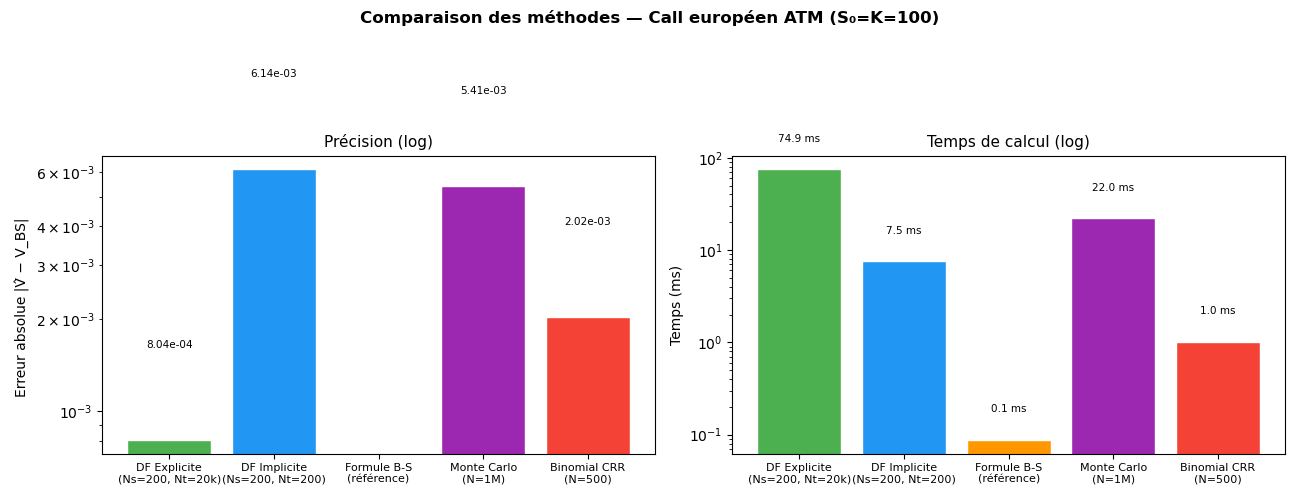

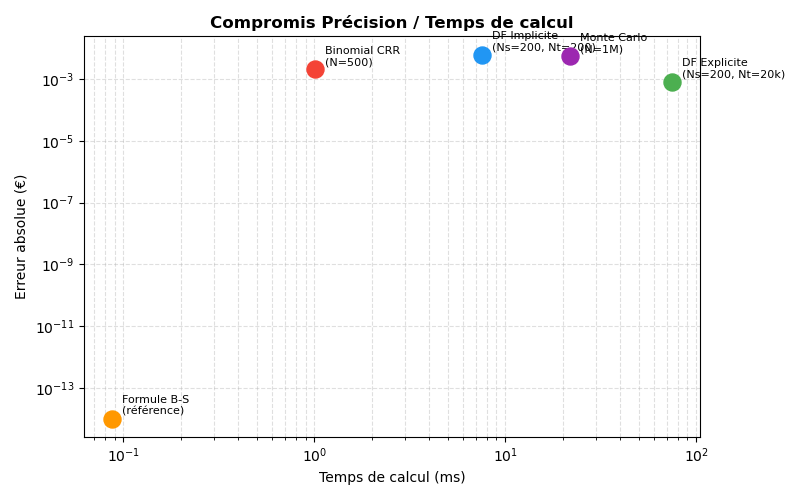

In [21]:
names  = list(results.keys())
errors = [results[n]['error'] for n in names]
times  = [results[n]['time']*1e3 for n in names]
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comparaison des méthodes — Call européen ATM (S₀=K=100)', fontsize=12, fontweight='bold')

# Précision
ax = axes[0]
bars = ax.bar(names, errors, color=colors, edgecolor='white')
ax.set_yscale('log')
ax.set_ylabel('Erreur absolue |V̂ − V_BS| ', fontsize=10)
ax.set_title('Précision (log)', fontsize=11)
ax.tick_params(axis='x', labelsize=8)
for bar, val in zip(bars, errors):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val*2, f'{val:.2e}', ha='center', fontsize=7.5)

# Temps
ax = axes[1]
bars = ax.bar(names, times, color=colors, edgecolor='white')
ax.set_yscale('log')
ax.set_ylabel('Temps (ms)', fontsize=10)
ax.set_title('Temps de calcul (log)', fontsize=11)
ax.tick_params(axis='x', labelsize=8)
for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, val*2, f'{val:.1f} ms', ha='center', fontsize=7.5)

plt.tight_layout()
plt.show()

#Diagramme Précision vs Temps
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title('Compromis Précision / Temps de calcul', fontsize=12, fontweight='bold')
for i, name in enumerate(names):
    x = results[name]['time']*1e3
    y = max(results[name]['error'], 1e-14)
    ax.scatter(x, y, s=150, color=colors[i], zorder=3)
    ax.annotate(name, (x, y), textcoords='offset points', xytext=(7, 3), fontsize=8)
ax.set_xlabel('Temps de calcul (ms)', fontsize=10)
ax.set_ylabel('Erreur absolue (€)', fontsize=10)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## Analyse des résultats
### Différences finies

On remarque que sans la condition CFL, la méthode implicite permet donc d'obtenir un temps de calcul beaucoup plus rapide, avec une précision acceptable. Cependant, malgré son temps de calcul élevé, la méthode explicite a fourni ici la meilleure précision.

### Monte Carlo
La méthode de Monte Carlo ici n'a pas été la plus intéressante : Sa vitesse de convergence en $ O(\frac{1}{\sqrt{N}}) $ est assez lente, et elle a démontré la précision la moins bonne. Cependant, comme cela a été rappelé plus haut, elle trouvera surtout son intérêt dans le pricing d'options plus exotiques, où les autres méthodes explicitées ici peuvent s'avérer inefficaces.

### Arbres binomiaux
Dans le cas des options européennes, cette méthode montre un excellent compromis vitesse/précision. 


Il est à noter ici que l'importance de la précision dépend de l'acheteur de l'option : Un particulier achetant quelques options ne se souciera pas d'une erreur de quelques dixièmes de centimes, alors qu'une instituion achetant des centaines de milliers d'options a tout intérêt à chercher la précision la plus fine.

## Regard critique sur le modèle Black-Scholes

Il est à noter que le modèle Black-Scholes requiert plusieurs hypothèses qui, dans le monde réel, sont totalement erronées. On peut citer notamment la volatilité constante (en réalité, la volatilité implicite peut fortement varier notamment dans le lorsque le strike change, et la volatilité implicite est très complexe à prédire), l'absence d'opportunité d'arbitrage, le taux d'intérêt sans risque constant..

### Exemple : Option Call BNP
En regardant sur Euronext, on peut trouver un Call BNP Paribas de strike $100$€, de prime par action valant 2€ (Le prix de l'option est de $200$ € car c'est un lot de 100 actions), expirant le 17 avril (soit $T = \frac{48 jours}{365 jours} = 0,13$). Le prix actuel est $95,5$ €.

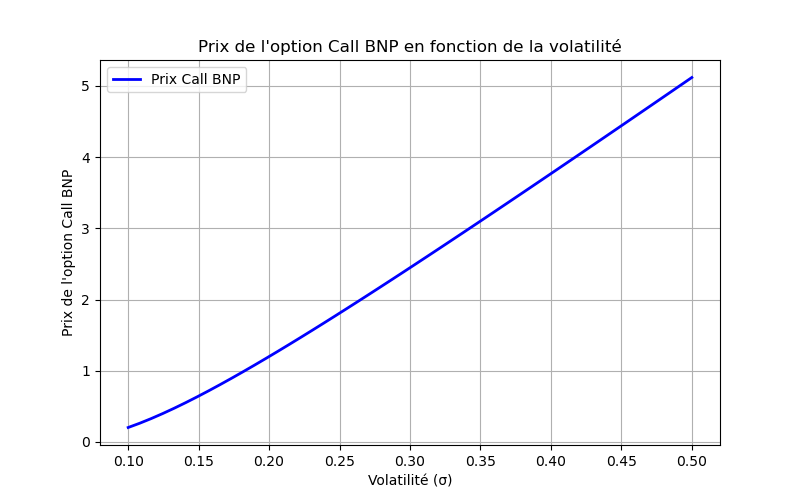

In [22]:


vols = np.linspace(0.1, 0.5, 50)
prix_bnp = [black_scholes_formula(95.5, 100, 0.13, 0.025 , sigma, option_type="call") for sigma in vols]

# Graphique
plt.figure(figsize=(8,5))
plt.plot(vols, prix_bnp, label="Prix Call BNP", color="blue", lw=2)
plt.xlabel("Volatilité (σ)")
plt.ylabel("Prix de l'option Call BNP")
plt.title("Prix de l'option Call BNP en fonction de la volatilité")
plt.grid(True)
plt.legend()
plt.show()

On observe que selon la volatilité que l'on choisit, on peut obtenir un résultat assez différent. On peut aussi inverser les résultats et déduire que nous avons une volatilité implicite d'environ $0,27$. Mais en prenant un autre call avec un autre strike et une autre maturité, on trouverait une autre volatilité implicite.. Ce qui montre les limites du modèle Black-Scholes.